# Pakistan property prices: sale price and rent prediction

**Goal:** estimate the sale price or monthly rent of a property from its city, neighbourhood, type, size (marla),
bedrooms and bathrooms, using ~100k listings scraped from a Pakistani property portal.

**Key points of this notebook:**
- **38% of the raw rows are exact duplicates.** The original cleaning missed them because of an index column, and duplicates
  landing in both train and test inflated the first version's R² to 0.985.
- Sales and rentals are **modelled separately**.
- Models are trained on log(price), with errors reported in rupees and as percentages, and compared with a price-per-marla baseline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

import house_model as hm

pd.set_option("display.float_format", "{:,.3f}".format)
raw = hm.load_raw()
print(raw.shape)
raw.head()

(99499, 8)


,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,Flat,10000000,G-10,Islamabad,2,For Sale,2,4.000
1,Flat,6900000,E-11,Islamabad,3,For Sale,3,5.600
2,House,16500000,G-15,Islamabad,6,For Sale,5,8.000
3,House,43500000,Bani Gala,Islamabad,4,For Sale,4,40.000
4,House,7000000,DHA Defence,Islamabad,3,For Sale,3,8.000


## 1. Data quality

In [2]:
print("Exact duplicate rows:", f"{raw.duplicated().sum():,} ({raw.duplicated().mean():.0%})")
print("Duplicates if the CSV index column is kept:", pd.read_csv(hm.DATA_PATH).duplicated().sum())
raw.groupby("purpose")["price"].describe(percentiles=[0.005, 0.5, 0.995])

Exact duplicate rows: 37,858 (38%)


Duplicates if the CSV index column is kept: 0


,count,mean,std,min,0.5%,50%,99.5%,max
purpose,,,,,,,,
For Rent,"28,552.000","85,189.021","143,545.709","15,500.000","16,000.000","50,000.000","600,000.000","12,500,000.000"
For Sale,"70,947.000","14,517,334.024","9,979,439.706","16,000.000","1,350,000.000","12,000,000.000","43,000,000.000","44,900,000.000"


The price scales are completely different: rents are tens of thousands of rupees per month, while sale prices are
tens of millions. Cleaning steps: strip whitespace, drop exact duplicates, drop zero-area listings, trim the extreme
0.5% of prices per purpose (mostly data-entry errors), and combine city + neighbourhood, because names such as
*DHA Defence* exist in several cities.

In [3]:
df, report = hm.clean(raw)
pd.Series(report, name="rows").to_frame()

,rows
raw rows,99499
after removing exact duplicates,61641
after removing zero area/price,61631
after trimming extreme prices,61141


## 2. Exploratory analysis

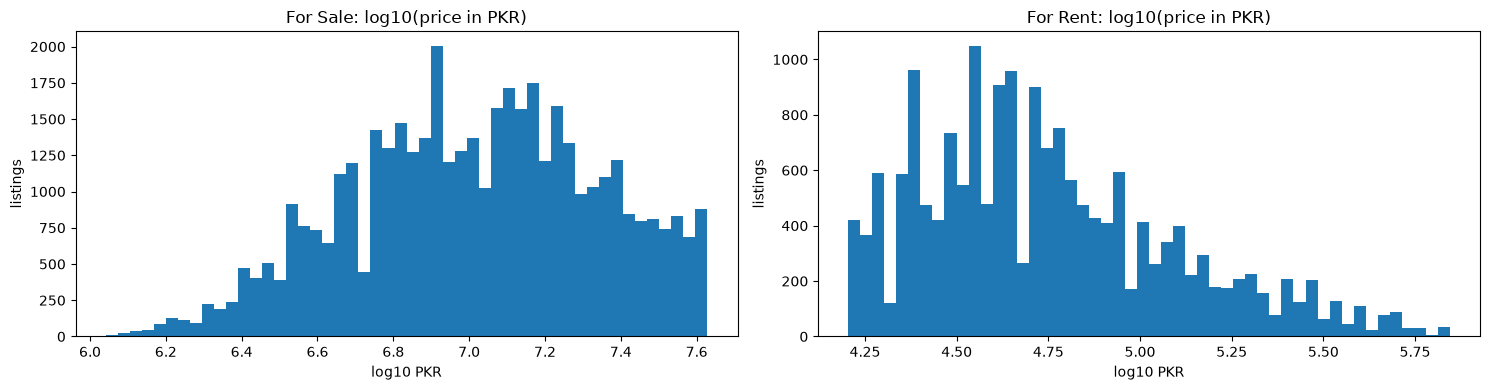

In [4]:
df["price_per_marla"] = df["price"] / df["Area_in_Marla"]
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, purpose in zip(axes, hm.PURPOSES):
    sub = df[df["purpose"] == purpose]
    ax.hist(np.log10(sub["price"]), bins=50)
    ax.set(title=f"{purpose}: log10(price in PKR)", xlabel="log10 PKR", ylabel="listings")
plt.tight_layout()

purpose,For Rent,For Sale
city,,
Faisalabad,"5,000","1,666,667"
Islamabad,"5,714","1,750,000"
Karachi,"6,809","1,744,186"
Lahore,nan,"1,937,500"
Rawalpindi,"4,848","1,545,455"


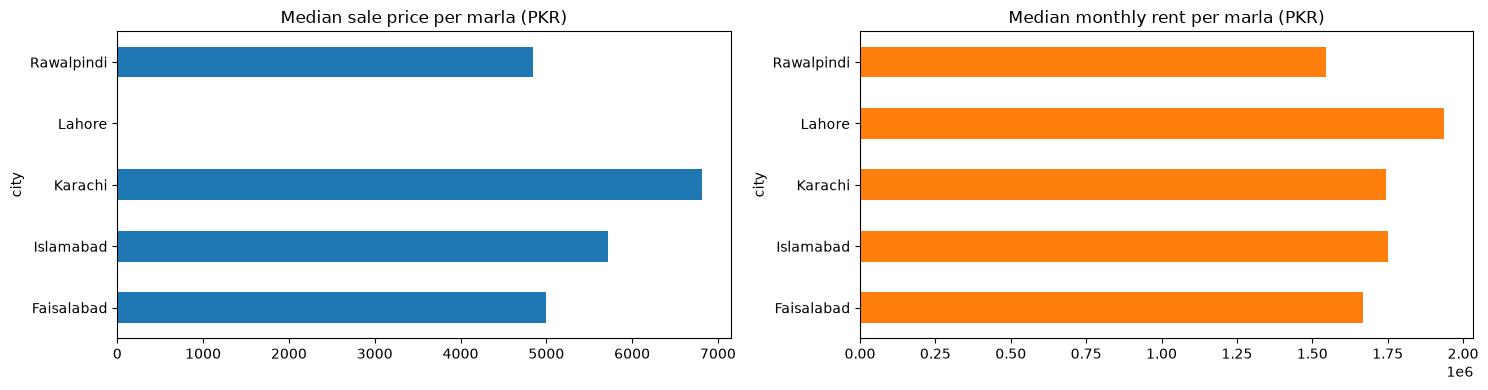

In [5]:
per_marla = df.groupby(["purpose", "city"])["price_per_marla"].median().unstack(0)
per_marla.plot.barh(subplots=True, layout=(1, 2), figsize=(15, 4), legend=False, sharex=False,
                    title=["Median sale price per marla (PKR)", "Median monthly rent per marla (PKR)"])
plt.tight_layout()
per_marla.style.format("{:,.0f}")

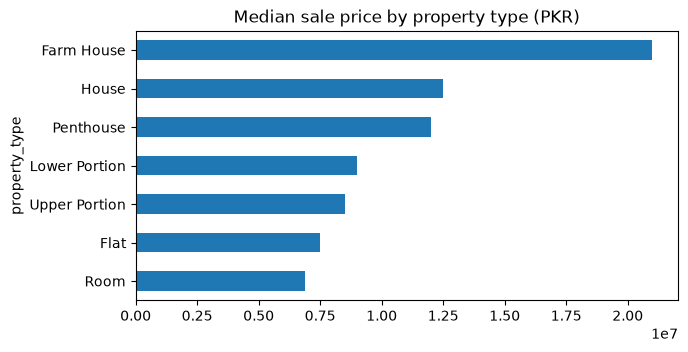

In [6]:
top = df[df["purpose"] == "For Sale"].groupby("property_type")["price"].median().sort_values()
top.plot.barh(figsize=(7, 3.5), title="Median sale price by property type (PKR)")
plt.show()

- **Lahore** has the highest median sale price per marla and **Karachi** the highest rent per marla.
- The dataset has **no rental listings for Lahore**, so the rent model can't be used for Lahore.
- Houses and farm houses sell for more than flats and portions. Much of that gap is plot size, which the model captures directly.

## 3. Models (random 80/20 split within each purpose)

In [7]:
results = {}
for purpose in hm.PURPOSES:
    metrics, scored = hm.compare_models(df, purpose)
    results[purpose] = scored
    print(purpose)
    display(metrics.style.format({"MAE (PKR)": "{:,.0f}", "MAPE": "{:.1%}", "Median APE": "{:.1%}", "R2": "{:.3f}"}))

For Sale


,MAE (PKR),MAPE,Median APE,R2
Baseline (median price per marla),"4,045,054",35.0%,21.2%,-0.374
Ridge regression (log price),"3,131,656",27.4%,18.2%,0.599
XGBoost (log price),"2,822,712",25.3%,17.9%,0.800


For Rent


,MAE (PKR),MAPE,Median APE,R2
Baseline (median price per marla),"32,193",40.3%,27.3%,0.428
Ridge regression (log price),"21,033",25.3%,18.9%,0.761
XGBoost (log price),"18,983",21.9%,16.9%,0.803


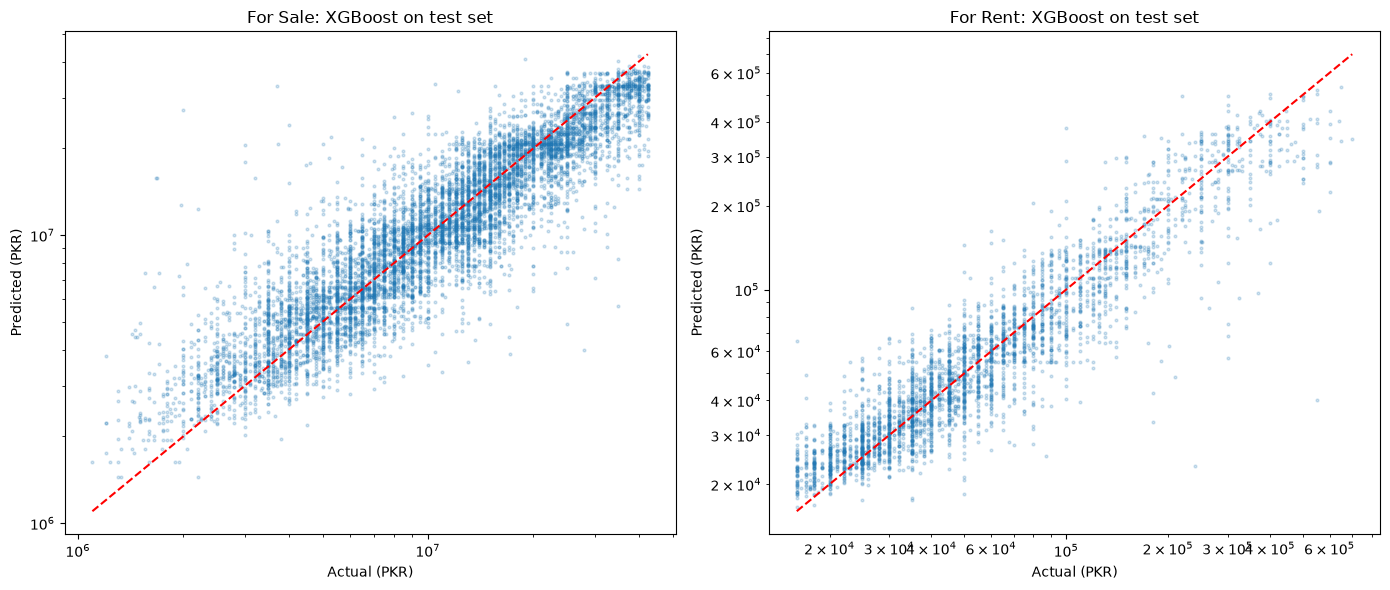

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (purpose, scored) in zip(axes, results.items()):
    ax.scatter(scored["price"], scored["predicted"], s=4, alpha=0.2)
    lo, hi = scored["price"].min(), scored["price"].max()
    ax.plot([lo, hi], [lo, hi], "r--")
    ax.set(xscale="log", yscale="log", xlabel="Actual (PKR)", ylabel="Predicted (PKR)", title=f"{purpose}: XGBoost on test set")
plt.tight_layout()

## 4. Where are the errors largest?

In [9]:
scored = results["For Sale"].assign(ape=lambda d: (d["predicted"] - d["price"]).abs() / d["price"])
scored.groupby("property_type")["ape"].agg(["median", "size"]).sort_values("median").style.format({"median": "{:.1%}"})

,median,size
property_type,,
Upper Portion,14.5%,246
House,16.9%,5727
Lower Portion,17.2%,105
Flat,20.5%,2500
Room,23.2%,3
Penthouse,28.7%,39
Farm House,44.2%,13


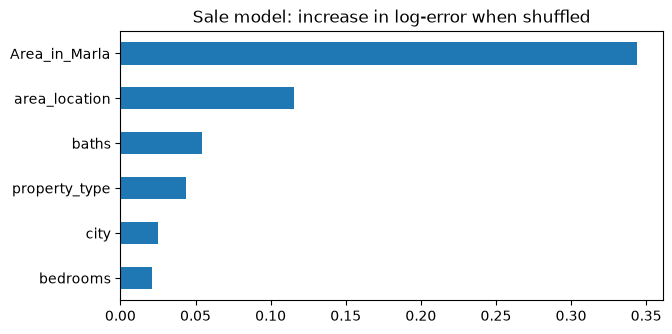

In [10]:
train, test = hm.split(df, "For Sale")
model = hm.make_xgb_model().fit(train[hm.FEATURES], train["price"])
sample = test.sample(3000, random_state=0)
imp = permutation_importance(model, sample[hm.FEATURES], np.log(sample["price"]),
                             scoring=lambda est, X, y: -np.mean(np.abs(np.log(est.predict(X)) - y)),
                             n_repeats=3, random_state=0)
pd.Series(imp.importances_mean, index=hm.FEATURES).sort_values().plot.barh(
    figsize=(7, 3.5), title="Sale model: increase in log-error when shuffled")
plt.show()

## 5. Conclusions

- After removing duplicates, XGBoost estimates a price within **about 18% (median)** for both sales and rents, with **R² ≈ 0.80**.
  It clearly beats the price-per-marla baseline (21–27%) and Ridge regression. The earlier R² of 0.985 came from duplicated listings.
- Plot size and neighbourhood carry most of the signal. Bedrooms and bathrooms add detail.
- Mean errors are larger than median errors because of a long tail of unusual listings (farm houses, very large plots, mispriced ads).

**Limitations:** listing prices are asking prices, not transaction prices. The data is a single snapshot with no
dates, so the model can't account for inflation. Near-duplicate listings (the same property re-posted at a different price) may
still make the scores slightly optimistic.